# AI Waste Sorter

### Project Overview
In this project we try to build an AI model that can classify the kind of waste into 12 classes from images.

# MobileNetV2 Transfer Learning

This project will use various transfer learning models. We will use MobileNetV2 and EfficientNet-b0 as transfer learning models and then compare the performance. For this notebook we will use MobileNetV2 transfer learning model.

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import json
from datetime import datetime
import gc

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models, callbacks, optimizers
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import MobileNetV2

from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

import warnings
warnings.filterwarnings('ignore')

print(f"TensorFlow version: {tf.__version__}")
print(f"GPU available: {tf.config.list_physical_devices('GPU')}")

if tf.config.list_physical_devices('GPU'):
    print("Using GPU")
    for gpu in tf.config.list_physical_devices('GPU'):
        tf.config.experimental.set_memory_growth(gpu, True)
else:
    print("Using CPU")

2026-02-05 19:20:29.254953: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


TensorFlow version: 2.20.0
GPU available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
Using GPU


## 1. Configuration & Setup

In [2]:
BASE_DIR = Path.cwd()
PROCESSED_DIR = BASE_DIR / 'processed_data'
TRAIN_DIR = PROCESSED_DIR / 'train_balanced'
VAL_DIR = PROCESSED_DIR / 'val'
TEST_DIR = PROCESSED_DIR / 'test'
MODELS_DIR = BASE_DIR / 'models'
MODELS_DIR.mkdir(exist_ok=True)

IMG_SIZE = (224, 224)
BATCH_SIZE = 32
EPOCHS = 100
NUM_CLASSES = 12

print(f"Image size: {IMG_SIZE}")
print(f"Batch size: {BATCH_SIZE}")
print(f"Epochs: {EPOCHS}")

Image size: (224, 224)
Batch size: 32
Epochs: 100


## 2. Data Generators with Augmentation

In [3]:
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.15,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest'
)

val_test_datagen = ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow_from_directory(
    TRAIN_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=True,
    seed=42
)

val_generator = val_test_datagen.flow_from_directory(
    VAL_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

test_generator = val_test_datagen.flow_from_directory(
    TEST_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

print(f"Train samples: {train_generator.samples}")
print(f"Validation samples: {val_generator.samples}")
print(f"Test samples: {test_generator.samples}")

Found 8424 images belonging to 12 classes.
Found 1550 images belonging to 12 classes.
Found 1556 images belonging to 12 classes.
Train samples: 8424
Validation samples: 1550
Test samples: 1556


# 3. Transfer Learning Model

For this transfer learning model we will use MobileNetV2 with imagenet weights and freeze the base model

In [4]:
def create_mobilenetv2_model(input_shape=(224, 224, 3), num_classes=12):
    """
    Create MobileNetV2 model with transfer learning
    """
    base_model = MobileNetV2(
        input_shape=input_shape,
        include_top=False,
        weights='imagenet',
        pooling='avg'
    )
    
    base_model.trainable = False
    
    model = models.Sequential([
        base_model,
        layers.Dense(256, activation='relu'),
        layers.BatchNormalization(),
        layers.Dropout(0.5),
        layers.Dense(128, activation='relu'),
        layers.BatchNormalization(),
        layers.Dropout(0.3),
        layers.Dense(num_classes, activation='softmax')
    ], name='MobileNetV2_Transfer')
    
    return model, base_model

model, base_model = create_mobilenetv2_model()
print(f"\nBase model (MobileNetV2) layers: {len(base_model.layers)}")
print(f"Base model trainable: {base_model.trainable}")
model.summary()

I0000 00:00:1770294076.075256   10172 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 1766 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 3050 Laptop GPU, pci bus id: 0000:01:00.0, compute capability: 8.6



Base model (MobileNetV2) layers: 155
Base model trainable: False


Model: "MobileNetV2_Transfer"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_224            │ (None, 1280)           │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 12)             │         1,548 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,621,900 (10.00 MB)

 Trainable params: 363,148 (1.39 MB)

 Non-trainable params: 2,258,752 (8.62 MB)

## 6. Training Configuration

In [5]:
def get_callbacks(model_name):
    model_path = MODELS_DIR / f'{model_name}_best.keras'
    
    callbacks_list = [
        callbacks.ModelCheckpoint(
            filepath=str(model_path),
            monitor='val_accuracy',
            save_best_only=True,
            mode='max',
            verbose=1
        ),
        callbacks.ReduceLROnPlateau(
            monitor='val_loss',
            factor=0.5,
            patience=5,
            min_lr=1e-7,
            verbose=1
        )
    ]
    
    return callbacks_list

print("Callbacks configured:")
print("- ModelCheckpoint to save best model based on val_accuracy")
print("- ReduceLROnPlateau to reduce LR by 0.5 if val_loss doesn't improve for 5 epochs")

Callbacks configured:
- ModelCheckpoint to save best model based on val_accuracy
- ReduceLROnPlateau to reduce LR by 0.5 if val_loss doesn't improve for 5 epochs


## 7. Phase 1: Train with Frozen Base Model

In [6]:
print("\nPhase 1: Train with frozen MobileNetV2 base")
print(f"Started at: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")

model.compile(
    optimizer=optimizers.Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

history_phase1 = model.fit(
    train_generator,
    epochs=30,
    validation_data=val_generator,
    callbacks=get_callbacks('mobilenetv2_phase1'),
    verbose=1
)

print(f"\nPhase 1 completed at: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")


Phase 1: Train with frozen MobileNetV2 base
Started at: 2026-02-05 19:21:18
Epoch 1/30


2026-02-05 19:21:23.503323: I external/local_xla/xla/service/service.cc:163] XLA service 0x7f8eac111630 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
2026-02-05 19:21:23.503363: I external/local_xla/xla/service/service.cc:171]   StreamExecutor device (0): NVIDIA GeForce RTX 3050 Laptop GPU, Compute Capability 8.6
2026-02-05 19:21:23.701496: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
2026-02-05 19:21:24.662358: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:473] Loaded cuDNN version 91801
2026-02-05 19:21:24.926546: I external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:208] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
2026-02-05 19:21:24.

126/264 ━━━━━━━━━━━━━━━━━━━━ 1:12 524ms/step - accuracy: 0.4345 - loss: 1.8967

2026-02-05 19:23:01.961721: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-02-05 19:23:02.180781: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-02-05 19:23:02.395360: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


264/264 ━━━━━━━━━━━━━━━━━━━━ 0s 568ms/step - accuracy: 0.5444 - loss: 1.4945

2026-02-05 19:24:49.153148: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-02-05 19:24:49.383527: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-02-05 19:24:49.596387: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-02-05 19:24:49.799794: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.



Epoch 1: val_accuracy improved from None to 0.91290, saving model to /mnt/d/personal/AI and Machine Learning/waste sorter ai/models/mobilenetv2_phase1_best.keras
264/264 ━━━━━━━━━━━━━━━━━━━━ 214s 706ms/step - accuracy: 0.6808 - loss: 1.0085 - val_accuracy: 0.9129 - val_loss: 0.2993 - learning_rate: 0.0010
Epoch 2/30
264/264 ━━━━━━━━━━━━━━━━━━━━ 0s 325ms/step - accuracy: 0.8139 - loss: 0.5772
Epoch 2: val_accuracy improved from 0.91290 to 0.91742, saving model to /mnt/d/personal/AI and Machine Learning/waste sorter ai/models/mobilenetv2_phase1_best.keras
264/264 ━━━━━━━━━━━━━━━━━━━━ 93s 352ms/step - accuracy: 0.8133 - loss: 0.5731 - val_accuracy: 0.9174 - val_loss: 0.2727 - learning_rate: 0.0010
Epoch 3/30
264/264 ━━━━━━━━━━━━━━━━━━━━ 0s 291ms/step - accuracy: 0.8420 - loss: 0.4763
Epoch 3: val_accuracy improved from 0.91742 to 0.92516, saving model to /mnt/d/personal/AI and Machine Learning/waste sorter ai/models/mobilenetv2_phase1_best.keras
264/264 ━━━━━━━━━━━━━━━━━━━━ 83s 314ms/ste

## 8. Phase 2: Fine-tuning with Unfrozen Top Layers

In [7]:
print("\nPhase 2: Fine-tuning with unfrozen top layers")
print(f"Started at: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")

base_model.trainable = True

fine_tune_at = 100
for layer in base_model.layers[:fine_tune_at]:
    layer.trainable = False

print(f"Unfrozen layers from {fine_tune_at} onwards")
print(f"Total trainable layers: {sum([1 for layer in model.layers if layer.trainable])}")

model.compile(
    optimizer=optimizers.Adam(learning_rate=0.0001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

history_phase2 = model.fit(
    train_generator,
    epochs=70,
    initial_epoch=30,
    validation_data=val_generator,
    callbacks=get_callbacks('mobilenetv2_final'),
    verbose=1
)

print(f"\nPhase 2 completed at: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")


Phase 2: Fine-tuning with unfrozen top layers
Started at: 2026-02-05 20:06:59
Unfrozen layers from 100 onwards
Total trainable layers: 8
Epoch 31/70


2026-02-05 20:07:14.540520: W external/local_xla/xla/tsl/framework/bfc_allocator.cc:382] Garbage collection: deallocate free memory regions (i.e., allocations) so that we can re-allocate a larger region to avoid OOM due to memory fragmentation. If you see this message frequently, you are running near the threshold of the available device memory and re-allocation may incur great performance overhead. You may try smaller batch sizes to observe the performance impact. Set TF_ENABLE_GPU_GARBAGE_COLLECTION=false if you'd like to disable this feature.


264/264 ━━━━━━━━━━━━━━━━━━━━ 0s 358ms/step - accuracy: 0.8390 - loss: 0.5659
Epoch 31: val_accuracy improved from None to 0.89226, saving model to /mnt/d/personal/AI and Machine Learning/waste sorter ai/models/mobilenetv2_final_best.keras
264/264 ━━━━━━━━━━━━━━━━━━━━ 130s 413ms/step - accuracy: 0.8592 - loss: 0.4773 - val_accuracy: 0.8923 - val_loss: 0.4096 - learning_rate: 1.0000e-04
Epoch 32/70
264/264 ━━━━━━━━━━━━━━━━━━━━ 0s 324ms/step - accuracy: 0.8944 - loss: 0.3051
Epoch 32: val_accuracy improved from 0.89226 to 0.90774, saving model to /mnt/d/personal/AI and Machine Learning/waste sorter ai/models/mobilenetv2_final_best.keras
264/264 ━━━━━━━━━━━━━━━━━━━━ 93s 352ms/step - accuracy: 0.9030 - loss: 0.2922 - val_accuracy: 0.9077 - val_loss: 0.3241 - learning_rate: 1.0000e-04
Epoch 33/70
264/264 ━━━━━━━━━━━━━━━━━━━━ 0s 293ms/step - accuracy: 0.9297 - loss: 0.2169
Epoch 33: val_accuracy did not improve from 0.90774
264/264 ━━━━━━━━━━━━━━━━━━━━ 83s 314ms/step - accuracy: 0.9262 - loss

## 9. Training history plot

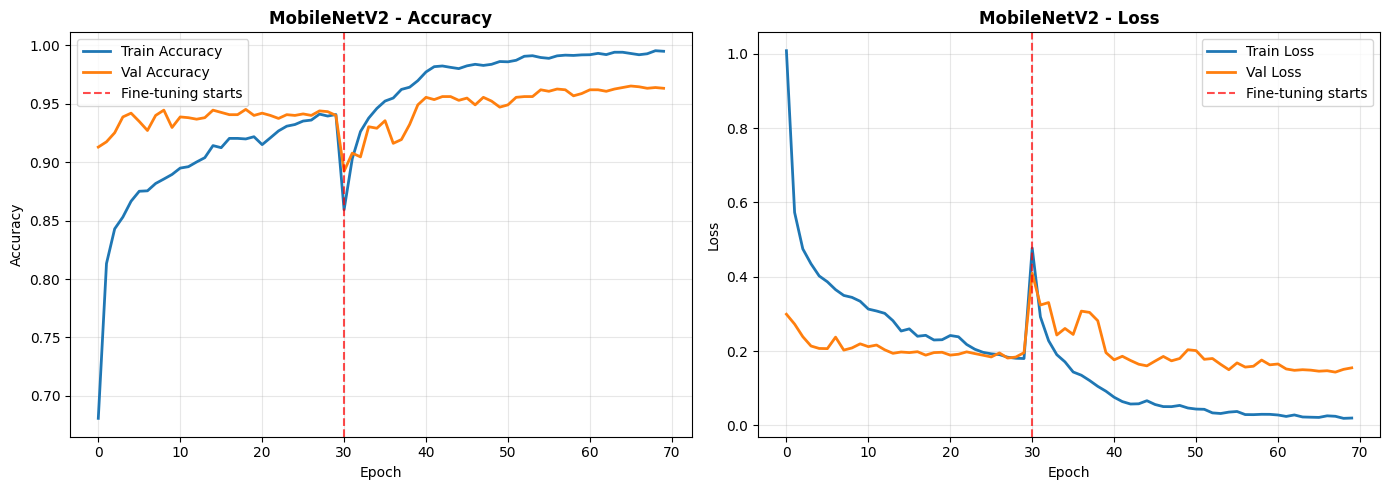

In [8]:
history_combined = {
    'accuracy': history_phase1.history['accuracy'] + history_phase2.history['accuracy'],
    'val_accuracy': history_phase1.history['val_accuracy'] + history_phase2.history['val_accuracy'],
    'loss': history_phase1.history['loss'] + history_phase2.history['loss'],
    'val_loss': history_phase1.history['val_loss'] + history_phase2.history['val_loss']
}

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history_combined['accuracy'], label='Train Accuracy', linewidth=2)
axes[0].plot(history_combined['val_accuracy'], label='Val Accuracy', linewidth=2)
axes[0].axvline(x=30, color='red', linestyle='--', label='Fine-tuning starts', alpha=0.7)
axes[0].set_title('MobileNetV2 - Accuracy', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(history_combined['loss'], label='Train Loss', linewidth=2)
axes[1].plot(history_combined['val_loss'], label='Val Loss', linewidth=2)
axes[1].axvline(x=30, color='red', linestyle='--', label='Fine-tuning starts', alpha=0.7)
axes[1].set_title('MobileNetV2 - Loss', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(MODELS_DIR / 'mobilenetv2_training_history.png', dpi=300, bbox_inches='tight')
plt.show()

## 10. Save model and classification report

In [9]:
model.load_weights(str(MODELS_DIR / 'mobilenetv2_final_best.keras'))

test_generator.reset()
predictions = model.predict(test_generator, verbose=1)
y_pred = np.argmax(predictions, axis=1)
y_true = test_generator.classes

accuracy = accuracy_score(y_true, y_pred)

class_names = list(test_generator.class_indices.keys())
report = classification_report(y_true, y_pred, target_names=class_names, digits=4)

print(f"\nMobileNetV2 Test Accuracy: {accuracy:.4f}")
print(f"\nClassification Report:")
print(report)

48/49 ━━━━━━━━━━━━━━━━━━━━ 0s 401ms/step

2026-02-05 21:03:56.515129: E external/local_xla/xla/service/slow_operation_alarm.cc:73] Trying algorithm eng3{k11=2} for conv (f32[20,576,14,14]{3,2,1,0}, u8[0]{0}) custom-call(f32[20,576,14,14]{3,2,1,0}, f32[576,1,3,3]{3,2,1,0}), window={size=3x3 pad=1_1x1_1}, dim_labels=bf01_oi01->bf01, feature_group_count=576, custom_call_target="__cudnn$convForward", backend_config={"operation_queue_id":"0","wait_on_operation_queues":[],"cudnn_conv_backend_config":{"activation_mode":"kNone","conv_result_scale":1,"side_input_scale":0,"leakyrelu_alpha":0},"force_earliest_schedule":false,"reification_cost":[]} is taking a while...
2026-02-05 21:03:56.899443: E external/local_xla/xla/service/slow_operation_alarm.cc:140] The operation took 1.384351029s
Trying algorithm eng3{k11=2} for conv (f32[20,576,14,14]{3,2,1,0}, u8[0]{0}) custom-call(f32[20,576,14,14]{3,2,1,0}, f32[576,1,3,3]{3,2,1,0}), window={size=3x3 pad=1_1x1_1}, dim_labels=bf01_oi01->bf01, feature_group_count=576, custom_call_target="__cudnn

49/49 ━━━━━━━━━━━━━━━━━━━━ 37s 688ms/step

MobileNetV2 Test Accuracy: 0.9704

Classification Report:
              precision    recall  f1-score   support

     battery     0.9789    0.9789    0.9789        95
  biological     0.9796    0.9697    0.9746        99
 brown-glass     0.9500    0.9344    0.9421        61
   cardboard     0.9885    0.9556    0.9718        90
     clothes     0.9943    0.9887    0.9915       533
 green-glass     0.9688    0.9841    0.9764        63
       metal     0.9136    0.9610    0.9367        77
       paper     0.9279    0.9810    0.9537       105
     plastic     0.9302    0.9195    0.9249        87
       shoes     0.9749    0.9798    0.9773       198
       trash     1.0000    0.9714    0.9855        70
 white-glass     0.9091    0.8974    0.9032        78

    accuracy                         0.9704      1556
   macro avg     0.9597    0.9601    0.9597      1556
weighted avg     0.9708    0.9704    0.9705      1556



## 11. Confussion matrix plot

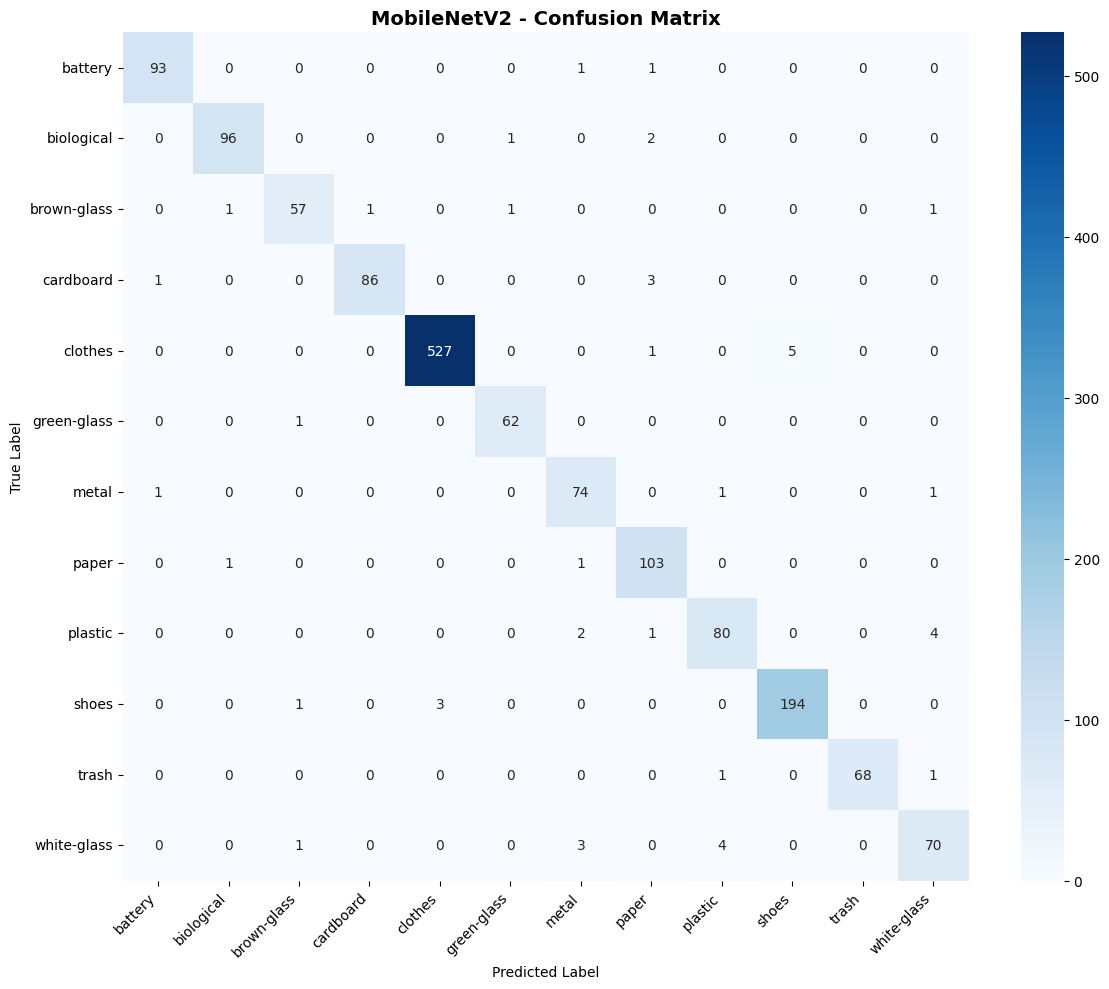

In [10]:
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(12, 10))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=class_names, yticklabels=class_names)
plt.title('MobileNetV2 - Confusion Matrix', fontsize=14, fontweight='bold')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig(MODELS_DIR / 'mobilenetv2_confusion_matrix.png', dpi=300, bbox_inches='tight')
plt.show()

## 11. Summary

In [11]:
results = {
    'model_name': 'MobileNetV2',
    'model_type': 'Transfer Learning',
    'timestamp': datetime.now().strftime('%Y-%m-%d %H:%M:%S'),
    'parameters': int(model.count_params()),
    'test_accuracy': float(accuracy),
    'best_val_accuracy': float(max(history_combined['val_accuracy'])),
    'final_train_accuracy': float(history_combined['accuracy'][-1]),
    'epochs_trained': len(history_combined['accuracy']),
    'training_phases': {
        'phase1_epochs': 30,
        'phase2_epochs': 70,
        'fine_tune_from_layer': 100
    },
    'configuration': {
        'image_size': IMG_SIZE,
        'batch_size': BATCH_SIZE,
        'max_epochs': EPOCHS,
        'base_model': 'MobileNetV2',
        'pretrained_weights': 'imagenet'
    }
}

with open(MODELS_DIR / 'mobilenetv2_results.json', 'w') as f:
    json.dump(results, f, indent=2)

print(f"\nSummary:")
print(f"Parameters: {results['parameters']:,}")
print(f"Test Accuracy: {results['test_accuracy']:.4f}")
print(f"Best Val Accuracy: {results['best_val_accuracy']:.4f}")
print(f"Epochs Trained: {results['epochs_trained']}")


Summary:
Parameters: 2,621,900
Test Accuracy: 0.9704
Best Val Accuracy: 0.9652
Epochs Trained: 70
